## Objectives
- Create a Keras-based convolutional neural network (CNN) model.
- Train the CNN model on agricultural and non-agricultural land dataset.
- Evaluate the performance of the CNN model.

## Create Keras Model

In [1]:
import os
import sys
import time
import shutil
import random
import numpy as np
import skillsnetwork
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [3]:
extract_dir = "./data"
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/4Z1fwRR295-1O3PMQBH6Dg/images-dataSAT.tar"

In [23]:
import tensorflow as tf
import platform

# 1. 获取物理设备列表
gpu_list = tf.config.list_physical_devices('GPU')

# 2. 兼容性判断逻辑
if gpu_list:
    device = "GPU"
elif platform.system() == "Darwin" and platform.processor() == "arm":
    # 针对 Apple Silicon (M1/M2/M3) 的检查
    # 如果安装了 tensorflow-metal，GPU 列表通常不为空，
    # 但显式检查系统环境可以增加代码的鲁棒性
    device = "MPS (Mac GPU)"
else:
    device = "CPU"

print(f"Device available for training: {device}")
print(f"List of GPUs found: {gpu_list}")

Device available for training: MPS (Mac GPU)
List of GPUs found: []


In [4]:
def check_skillnetwork_extraction(extract_dir):
    """ function to check whether data download and extraction method
    `skillsnetwork.prepare` would execute successfully, without downloading any data.
    This helps in early detection and fast fallback to explicit download and extraction
    using default libraries
    ###This is a hack for the code to run on non-cloud computing environment without errors
    """
    symlink_test = os.path.join(extract_dir, "symlink_test")
    if not os.path.exists(symlink_test):
        os.symlink(os.path.join(os.sep, "tmp"), symlink_test)
        print("Write permissions available for downloading and extracting the dataset tar file")
    os.unlink(symlink_test)

async def download_tar_dataset(url, tar_path, extract_dir):
    """function to explicitly download and extract the dataset tar file from cloud using native python libraries
    """
    if not os.path.exists(tar_path): # download only if file not downloaded already
        try:
            print(f"Downloading from {url}...")
            async with httpx.AsyncClient() as client:
                response = await client.get(url, follow_redirects=True)# Download the file asynchronously
                response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)

                with open(tar_path , "wb") as f:
                    f.write(response.content) # Save the downloaded file
                print(f"Successfully downloaded '{file_name}'.")
        except httpx.HTTPStatusError as http_err:
            print(f"HTTP error occurred during download: {http_err}")
        except Exception as download_err:
            print(f"An error occurred during the fallback process: {download_err}")
    else:
        print(f"dataset tar file already downloaded at: {tar_path}")
    with tarfile.open(tar_path, 'r:*') as tar_ref:
        tar_ref.extractall(path=extract_dir)
    print(f"Successfully extracted to '{extract_dir}'.")

In [5]:
try:
    check_skillnetwork_extraction(extract_dir)
    await skillsnetwork.prepare(url = url, path = extract_dir, overwrite = True)
except Exception as e:
    print(e)
    # --- FALLBACK METHOD FOR DOWNLOADING THE DATA ---
    print("Primary download/extration method failed.")
    print("Falling back to manual download and extraction...")

    # import libraries required for downloading and extraction
    import tarfile
    import httpx
    from pathlib import Path

    file_name = Path(url).name# Get the filename from the URL (for example, 'data.tar')
    tar_path = os.path.join(extract_dir, file_name)
    print(f"tar_path: {os.path.exists(tar_path)} ___ {tar_path}")
    await download_tar_dataset(url, tar_path, extract_dir)

Write permissions available for downloading and extracting the dataset tar file


  0%|          | 0/6003 [00:00<?, ?it/s]

Saved to 'data'


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.initializers import HeUniform
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import accuracy_score
print("Succesfully imported the libraries")

Succesfully imported the libraries


In [7]:
seed_value = 7331
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

In [8]:
dataset_path = os.path.join(extract_dir, "images_dataSAT")
print(dataset_path)

./data/images_dataSAT


In [11]:
fnames = []
for dirname,_,filenames in os.walk(dataset_path):
    for fn in filenames:
        full_path = os.path.join(dirname, fn)
        fnames.append(full_path)
print(f"total files in dataset: {len(fnames)}")

total files in dataset: 6000


### Define Hypterparameters

In [12]:
img_w, img_h = 64, 64
n_channels = 3
batch_size = 128
lr = 0.001 # Learning rate
n_epochs = 3 # set to low number for your convenience. You can change this to any number of your liking

steps_per_epoch = None
validation_steps = None

model_name = "ai_capstone_keras_best_model.model.keras"

In [13]:
datagen = ImageDataGenerator(rescale=1./255,
                             rotation_range=40,
                             width_shift_range=0.2,
                             height_shift_range=0.2,
                             shear_range=0.2,
                             zoom_range=0.2,
                             horizontal_flip=True,
                             fill_mode="nearest",
                             validation_split=0.2
                            )

In [14]:
train_generator = datagen.flow_from_directory(dataset_path,
 target_size = (img_w, img_h),
 batch_size= batch_size,
 class_mode="binary",
 subset="training"
 )

Found 4800 images belonging to 2 classes.


In [15]:
validation_generator = datagen.flow_from_directory(dataset_path,
 target_size = (img_w, img_h),
 batch_size= batch_size,
 class_mode="binary",
 subset="validation"
 )

Found 1200 images belonging to 2 classes.


##### Training 和 Validataion 这两个标签是哪里定义？

这是Keras在ImageDataGenerator内容内置的逻辑，数据按validation_split拆分好后，存入training和validation两个目录下，内置的。

In [16]:
model = Sequential([
                    Conv2D(32 , (5,5) , activation="relu",padding="same",strides=(1,1), kernel_initializer=HeUniform(), input_shape=(img_w, img_h, n_channels)),
                    MaxPooling2D(2,2),
                    BatchNormalization(),

                    Conv2D(64, (5,5) , activation="relu",padding="same" , strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),

                    Conv2D(128, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),

                    ###
                    Conv2D(256, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),

                    Conv2D(512, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),

                    Conv2D(1024, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
                    MaxPooling2D(2,2),
                    BatchNormalization(),


                    ###
                    GlobalAveragePooling2D(),

                    Dense(64,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),

                    Dense(128,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),

                    Dense(256,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),

                    ###
                    Dense(512,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),

                    Dense(1024,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),

                    Dense(2048,activation="relu" , kernel_initializer=HeUniform()),
                    BatchNormalization(),
                    Dropout(0.4),


                    ###
                    Dense(1 , activation="sigmoid")

                ])

/Users/jimmy/miniforge3/envs/ai_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### HeUniform是什么？
在深度学习中，HeUniform（也称为 Kaiming Uniform）是一种专门为使用 ReLU 及其变体（如 LeakyReLU）作为激活函数的深层神经网络设计的权重初始化方法。

In [17]:
loss = "binary_crossentropy"
model.compile(optimizer=Adam(learning_rate=lr),
              loss=loss,
              metrics=["accuracy"])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 512)      │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 1024)     │    13,108,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1, 1, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 20,352,897 (77.64 MB)

 Trainable params: 20,340,801 (77.59 MB)

 Non-trainable params: 12,096 (47.25 KB)

None


#### 这个模型有多少层？

38层 （注意正则化和Dropout也是一个独立的神经层）

#### 为什么 BatchNormalization 和 Dropout 是一个独立的神经层？
- 包含可学习参数
- 有状态存储

### Create and compile a CNN model test_model with 4 Conv2D layers and 5 Dense layers.

In [18]:
model = Sequential([
    Conv2D(32, (5, 5), activation="relu", padding="same", strides=(1, 1), kernel_initializer=HeUniform(),
           input_shape=(img_w, img_h, n_channels)),
    MaxPooling2D(2, 2),
    BatchNormalization(),

    Conv2D(64, (5, 5), activation="relu", padding="same", strides=(1, 1), kernel_initializer=HeUniform()),
    MaxPooling2D(2, 2),
    BatchNormalization(),

    Conv2D(128, (5, 5), activation="relu", padding="same", strides=(1, 1), kernel_initializer=HeUniform()),
    MaxPooling2D(2, 2),
    BatchNormalization(),

    ###
    Conv2D(256, (5, 5), activation="relu", padding="same", strides=(1, 1), kernel_initializer=HeUniform()),
    MaxPooling2D(2, 2),
    BatchNormalization(),


    ###
    GlobalAveragePooling2D(),

    Dense(64, activation="relu", kernel_initializer=HeUniform()),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation="relu", kernel_initializer=HeUniform()),
    BatchNormalization(),
    Dropout(0.4),

    Dense(1024, activation="relu", kernel_initializer=HeUniform()),
    BatchNormalization(),
    Dropout(0.4),

    Dense(2048, activation="relu", kernel_initializer=HeUniform()),
    BatchNormalization(),
    Dropout(0.4),

    ###
    Dense(1, activation="sigmoid")

])

In [19]:
loss = "binary_crossentropy"
model.compile(optimizer=Adam(learning_rate=lr),loss=loss, metrics=["accuracy"])

## Train the model

In [20]:
checkpoint_cb = ModelCheckpoint(filepath=model_name,
                                monitor='val_loss',      # or 'val_accuracy'
                                mode='min',              # 'min' for loss, 'max' for accuracy
                                save_best_only=True,
                                verbose=1
                               )

In [21]:
checkpoint_cb_max = ModelCheckpoint(filepath=model_name,
                                monitor='val_accuracy',      # or 'val_accuracy'
                                mode='max',              # 'min' for loss, 'max' for accuracy
                                save_best_only=True,
                                verbose=1
                               )

In [24]:
print(f"Training on : ==={device}=== with batch size: {batch_size} & lr: {lr}")

fit = model.fit(train_generator,
                epochs= n_epochs,
                steps_per_epoch = steps_per_epoch,
                validation_data=(validation_generator),
                validation_steps = validation_steps,
                callbacks=[checkpoint_cb],
                verbose=1
               )

Training on : ===MPS (Mac GPU)=== with batch size: 128 & lr: 0.001
Epoch 1/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.8680 - loss: 0.3702
Epoch 1: val_loss improved from None to 16.82380, saving model to ai_capstone_keras_best_model.model.keras

Epoch 1: finished saving model to ai_capstone_keras_best_model.model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 26s 577ms/step - accuracy: 0.9331 - loss: 0.2257 - val_accuracy: 0.6325 - val_loss: 16.8238
Epoch 2/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.9664 - loss: 0.1190
Epoch 2: val_loss improved from 16.82380 to 4.53679, saving model to ai_capstone_keras_best_model.model.keras

Epoch 2: finished saving model to ai_capstone_keras_best_model.model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 578ms/step - accuracy: 0.9702 - loss: 0.1105 - val_accuracy: 0.5883 - val_loss: 4.5368
Epoch 3/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.9809 - loss: 0.0571
Epoch 3: val_loss improved from 4.53679 to 2.79172, saving model to ai_c

## Model Evaluation

In [25]:
steps = int(np.ceil(validation_generator.samples / validation_generator.batch_size))
batch_size = int(validation_generator.batch_size)

all_preds = []
all_labels = []
for step in range(steps):
    # Get one batch data
    images, labels = next(validation_generator)
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int).flatten()
    all_preds.extend(preds)
    all_labels.extend(labels)
accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy Score: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Accuracy Score: 0.5317


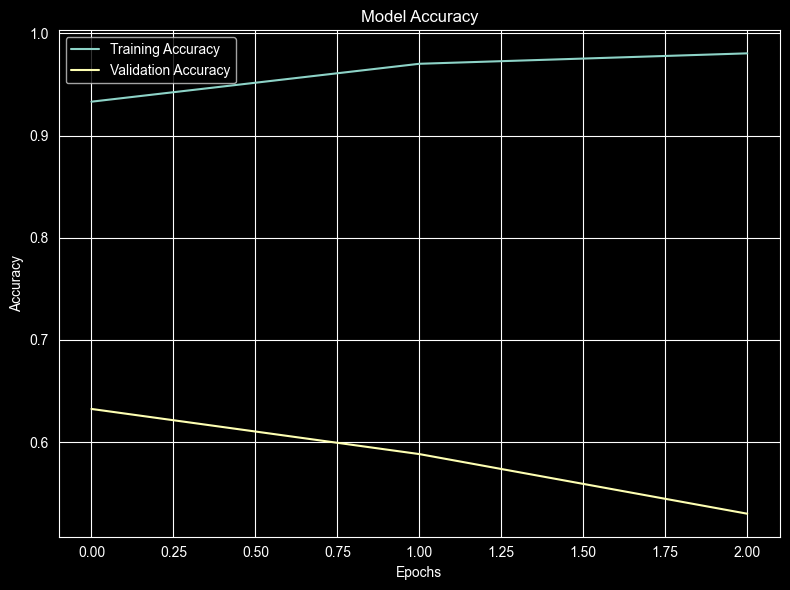

In [26]:
fig, axs = plt.subplots(figsize=(8, 6))

# Plot Accuracy on the first subplot
axs.plot(fit.history['accuracy'], label='Training Accuracy')
axs.plot(fit.history['val_accuracy'], label='Validation Accuracy')
axs.set_title('Model Accuracy')
axs.set_xlabel('Epochs')
axs.set_ylabel('Accuracy')
axs.legend()
axs.grid(True)

plt.tight_layout()
plt.show()

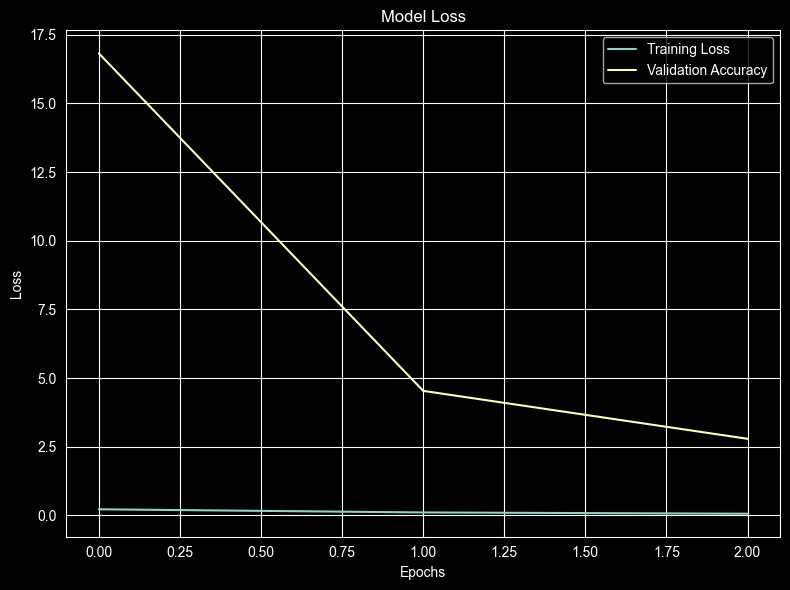

In [29]:
fig, axs = plt.subplots(figsize=(8, 6))

# Plot Accuracy on the first subplot
axs.plot(fit.history['loss'], label='Training Loss')
axs.plot(fit.history['val_loss'], label='Validation Accuracy')
axs.set_title('Model Loss')
axs.set_xlabel('Epochs')
axs.set_ylabel('Loss')
axs.legend()
axs.grid(True)

plt.tight_layout()
plt.show()